In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/19-heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

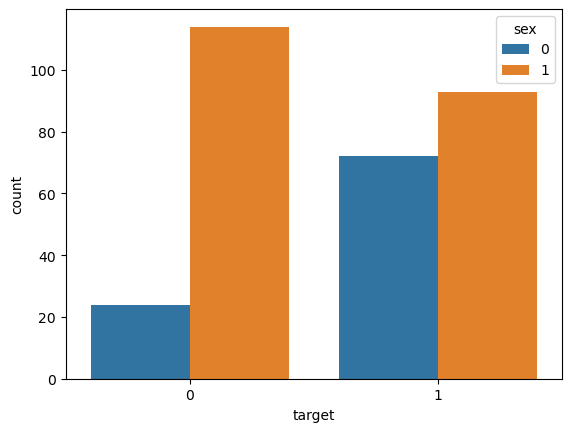

In [13]:
sns.countplot(x = df["target"], hue = df["sex"])

In [14]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<Axes: >

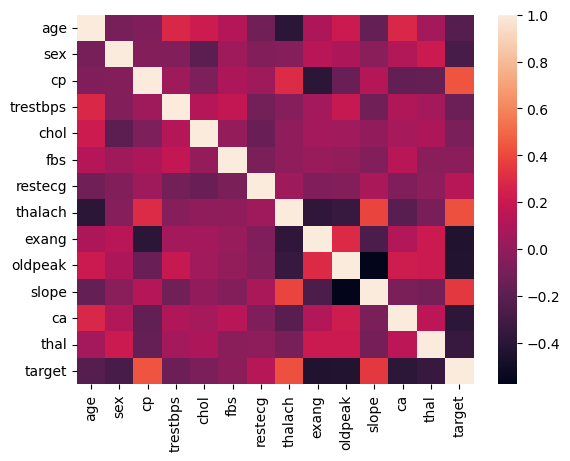

In [15]:
sns.heatmap(
    df.corr()
)

<Axes: xlabel='target', ylabel='age'>

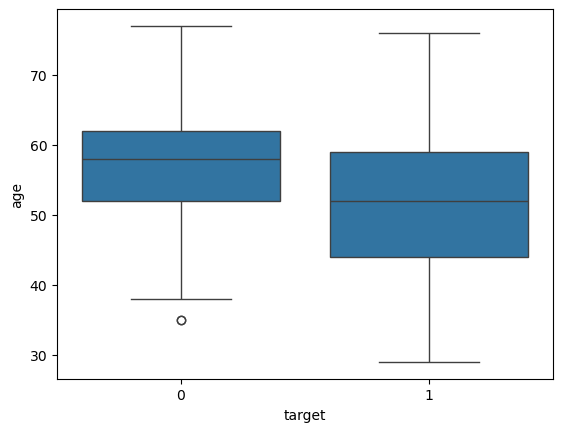

In [16]:
sns.boxplot(x="target", y="age", data=df)

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
boost = GradientBoostingClassifier(n_estimators= 100, learning_rate= 0.1, max_depth= 3)

In [23]:
X = df.drop("target", axis= 1)
y = df["target"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state= 42
)

In [25]:
boost.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [26]:
y_pred = boost.predict(X_test)

In [28]:
print("accuracy_score: ", accuracy_score(y_test, y_pred))
print("matrix: ", confusion_matrix(y_test, y_pred))
print("classification_report: ", classification_report(y_test, y_pred))
print("train_score: ", boost.score(X_train, y_train))

accuracy_score:  0.7704918032786885
matrix:  [[23  6]
 [ 8 24]]
classification_report:                precision    recall  f1-score   support

           0       0.74      0.79      0.77        29
           1       0.80      0.75      0.77        32

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61

train_score:  1.0


In [29]:
boost = GradientBoostingClassifier(n_estimators= 50, learning_rate= 0.05, max_depth= 1)
boost.fit(X_train, y_train)
y_pred = boost.predict(X_test)
print("accuracy_score: ", accuracy_score(y_test, y_pred))
print("matrix: ", confusion_matrix(y_test, y_pred))
print("classification_report: ", classification_report(y_test, y_pred))
print("train_score: ", boost.score(X_train, y_train))

accuracy_score:  0.8524590163934426
matrix:  [[24  5]
 [ 4 28]]
classification_report:                precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

train_score:  0.8553719008264463


In [30]:
boost.feature_importances_

array([0.        , 0.        , 0.21638822, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.10976223, 0.11449422,
       0.06290696, 0.28252895, 0.21391943])

In [36]:
importance_df = pd.DataFrame({
    "importance" : boost.feature_importances_,
    "col" : X_train.columns
}
)

In [46]:
sorted_importance = importance_df.sort_values(by = "importance", ascending= False)

Text(0.5, 1.0, 'feature importance')

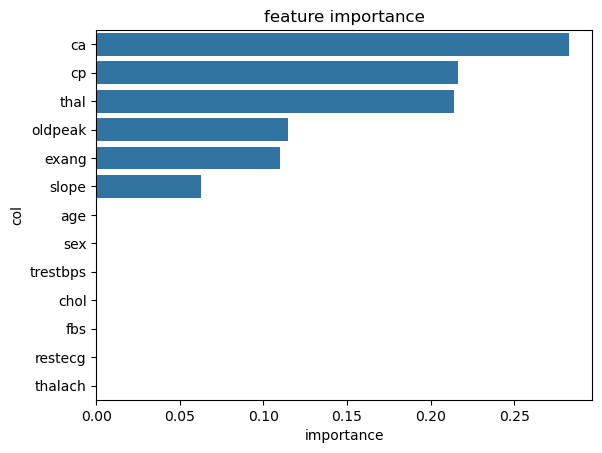

In [48]:
sns.barplot(
    data=sorted_importance,
    y="col",
    x="importance"
)
plt.title("feature importance")

In [50]:
boost.feature_importances_

array([0.        , 0.        , 0.21638822, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.10976223, 0.11449422,
       0.06290696, 0.28252895, 0.21391943])

In [51]:
importance_df["importance"].round(6)

0     0.000000
1     0.000000
2     0.216388
3     0.000000
4     0.000000
5     0.000000
6     0.000000
7     0.000000
8     0.109762
9     0.114494
10    0.062907
11    0.282529
12    0.213919
Name: importance, dtype: float64